In [ ]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import numpy as np
from scipy.integrate import solve_ivp
import os
import time

class UnbalancedDisk(gym.Env):
    def __init__(self, umax=20., dt=0.025, render_mode='human'):
        self.omega0 = 11.339846957335382
        self.delta_th = 0
        self.gamma = 1.3328339309394384
        self.Ku = 28.136158407237073
        self.Fc = 6.062729509386865
        self.coulomb_omega = 0.001

        self.umax = umax
        self.dt = dt 

        self.action_space = spaces.Box(low=-umax, high=umax, shape=tuple()) 
        low = [-float('inf'), -40] 
        high = [float('inf'), 40]
        self.observation_space = spaces.Box(low=np.array(low, dtype=np.float32), high=np.array(high, dtype=np.float32), shape=(2,))

        # --- UPDATED REWARD FUNCTION ---
        # Smooth gradient: +1 at the top, -1 at the bottom, small penalty for high speed, penalty for high inputs and penalty for high changes in input
        self.reward_fun = lambda self: np.cos(self.th - np.pi) - 0.001 * (self.omega**2) - 0.01 * self.u**2 - 0.005 * (self.u - self.prev_u)**2
        
        self.render_mode = render_mode
        self.viewer = None
        self.u = 0 
        self.reset()

    def step(self, action):
        prev_u = self.u
        self.u = action 
        self.u = np.clip(self.u, -self.umax, self.umax)
        
        def f(t,y):
            th, omega = y
            dthdt = omega
            friction = self.gamma*omega + self.Fc*np.tanh(omega/self.coulomb_omega)
            domegadt = -self.omega0**2*np.sin(th+self.delta_th) - friction + self.Ku*self.u
            return np.array([dthdt, domegadt])
            
        sol = solve_ivp(f, [0, self.dt], [self.th, self.omega]) 
        self.th, self.omega = sol.y[:, -1]
        #Add random disturbance 1% of the time
        #if np.random.rand() < 0.01:
            #self.omega += np.random.uniform(-0.5, 0.5)

        reward = self.reward_fun(self)
        return self.get_obs(), reward, False, False, {}
         
    def reset(self, seed=None, options=None):
        super().reset(seed=seed) 
        self.th = np.random.normal(loc=0, scale=0.001)
        self.omega = np.random.uniform(-1.0, 1.0)
        self.u = 0
        self.prev_u = 0
        return self.get_obs(), {}

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0, scale=0.005) 
        self.omega_noise = self.omega + np.random.normal(loc=0, scale=0.005) #Increased distrubances from 0.001 to 0.005
        return np.array([self.th_noise, self.omega_noise/40]) #Omega/40 as normalization

    def render(self):
        import pygame
        from pygame import gfxdraw
        screen_width, screen_height = 500, 500
        th, omega = self.th, self.omega 

        if self.viewer is None:
            pygame.init()
            pygame.display.init()
            self.viewer = pygame.display.set_mode((screen_width, screen_height))

        self.surf = pygame.Surface((screen_width, screen_height))
        self.surf.fill((255, 255, 255))
        gfxdraw.filled_circle(self.surf, screen_width//2, screen_height//2, int(screen_width/2*0.65*1.3), (32,60,92))
        gfxdraw.filled_circle(self.surf, screen_width//2, screen_height//2, int(screen_width/2*0.06*1.3), (132,132,126))
        
        from math import cos, sin
        r = screen_width//2*0.40*1.3
        gfxdraw.filled_circle(self.surf, int(screen_width//2-sin(th)*r), int(screen_height//2-cos(th)*r), int(screen_width/2*0.22*1.3), (155,140,108))
        gfxdraw.filled_circle(self.surf, int(screen_width//2-sin(th)*r), int(screen_height//2-cos(th)*r), int(screen_width/2*0.22/8*1.3), (71,63,48))
        
        fname = os.path.join(os.getcwd(), "clockwise.png")
        try:
            self.arrow = pygame.image.load(fname)
            if self.u:
                u = self.u[0] if isinstance(self.u, (np.ndarray, list)) and len(self.u) > 0 else float(self.u)
                arrow_size = abs(float(u)/self.umax*screen_height)*0.25
                Z = (arrow_size, arrow_size)
                arrow_rot = pygame.transform.scale(self.arrow, Z)
                if self.u < 0:
                    arrow_rot = pygame.transform.flip(arrow_rot, True, False)
            self.surf = pygame.transform.flip(self.surf, False, True)
            self.viewer.blit(self.surf, (0, 0))
            if self.u:
                self.viewer.blit(arrow_rot, (screen_width//2-arrow_size//2, screen_height//2-arrow_size//2))
        except FileNotFoundError:
            self.surf = pygame.transform.flip(self.surf, False, True)
            self.viewer.blit(self.surf, (0, 0))
            
        if self.render_mode == "human":
            pygame.event.pump()
            pygame.display.flip()
        return True

    def close(self):
        if self.viewer is not None:
            import pygame
            pygame.display.quit()
            pygame.quit()
            self.isopen = False
            self.viewer = None

class UnbalancedDisk_sincos(UnbalancedDisk):
    def __init__(self, umax=3., dt=0.025):
        super().__init__(umax=umax, dt=dt)
        low, high = [-1, -1, -1.], [1, 1, 1.] #Changed from [1,1,40] to [1,1,1] (normalization omega in get_obs)
        self.observation_space = spaces.Box(low=np.array(low, dtype=np.float32), high=np.array(high, dtype=np.float32), shape=(3,))

    def get_obs(self):
        self.th_noise = self.th + np.random.normal(loc=0, scale=0.001) 
        self.omega_noise = self.omega + np.random.normal(loc=0, scale=0.001) 
        return np.array([np.sin(self.th_noise), np.cos(self.th_noise), self.omega_noise], dtype=np.float32)

class DiscretizeAction(gym.ActionWrapper):
    def __init__(self, env, bins=7):
        super().__init__(env)
        self.bins = bins
        self.action_space = gym.spaces.Discrete(self.bins)
        low = np.atleast_1d(env.action_space.low)[0]
        high = np.atleast_1d(env.action_space.high)[0]
        self.action_mapping = np.linspace(low, high, self.bins)

    def action(self, act):
        return float(self.action_mapping[act])

In [82]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# 1. The Neural Network (Approximates the Q-Table)
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        # A simple Multi-Layer Perceptron (MLP)
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

# 2. The Replay Buffer (Stores past experiences)
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.array(next_states), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32).unsqueeze(1)
        )
        
    def __len__(self):
        return len(self.buffer)

In [83]:
def train_dqn(env, episodes=500, batch_size=64, gamma=0.99, lr=1e-3, tau=0.005):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    # We use TWO networks for stability
    policy_net = QNetwork(state_dim, action_dim)
    target_net = QNetwork(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    memory = ReplayBuffer()
    
    eps_start, eps_end, eps_decay = 1.0, 0.05, 40000
    steps_done = 0
    
    history = {
        "episode_rewards": [],
        "episode_lengths": [],
        "losses": [],
        "epsilons": []
    }

    print("Starting DQN Training...")
    
    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        episode_length = 0
        done = False
        episode_losses = []
        
        while not done:
            # Epsilon-Greedy Action Selection
            eps_threshold = eps_end + (eps_start - eps_end) * np.exp(-1. * steps_done / eps_decay)
            steps_done += 1
            
            if random.random() > eps_threshold:
                with torch.no_grad():
                    q_values = policy_net(torch.tensor(state, dtype=torch.float32))
                    action = q_values.argmax().item()
            else:
                action = env.action_space.sample()
                
            # take step and store in buffer
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            memory.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            episode_length += 1 #Increase episode length by 1
            
            # train the network if we have enough data
            if len(memory) > batch_size:
                states, actions, rewards, next_states, dones = memory.sample(batch_size)
                
                # compute Current Q values
                current_q = policy_net(states).gather(1, actions)
                
                # compute Target Q values
                with torch.no_grad():
                    max_next_q = target_net(next_states).max(1)[0].unsqueeze(1)
                    target_q = rewards + (gamma * max_next_q * (1 - dones))
                
                # compute Loss and Optimize
                loss = nn.SmoothL1Loss()(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                episode_losses.append(loss.item())
                # soft update the target network
                for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                    target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)
        
        history["episode_rewards"].append(total_reward)
        history["episode_lengths"].append(episode_length)
        history["epsilons"].append(eps_threshold)

        if len(episode_losses) > 0:
            history["losses"].append(np.mean(episode_losses))
        else:
            history["losses"].append(np.nan)

        if (episode + 1) % 10 == 0:
            avg_reward = np.mean(history["episode_rewards"][-10:])
            print(
                f"Episode {episode + 1}/{episodes} | "
                f"Reward: {total_reward:.2f} | "
                f"Avg reward: {avg_reward:.2f} | "
                f"Epsilon: {eps_threshold:.2f}"
            )
            
    print("DQN Training Complete!")
    return policy_net, history

### Train the Model

In [84]:
env = UnbalancedDisk_sincos(umax=3.0, dt=0.025)
env = TimeLimit(env, max_episode_steps=200)
#Discretize the actions into 11 bins
env = DiscretizeAction(env, bins=11)
#Train the DQN
trained_policy, history = train_dqn(env, episodes=600, batch_size=64, gamma=0.99, lr=2e-4, tau=0.005)

print("Testing Trained DQN Agent...")
obs, _ = env.reset()

try:
    for i in range(500):
        
        with torch.no_grad():
            q_values = trained_policy(torch.tensor(obs, dtype=torch.float32))
            action = q_values.argmax().item()
            
        obs, reward, terminated, truncated, _ = env.step(action)
        env.render()
        time.sleep(0.025)
        
        if terminated or truncated:
            obs, _ = env.reset()
            
finally:
    env.close()

Starting DQN Training...
Episode 10/600 | Reward: -205.86 | Avg reward: -204.63 | Epsilon: 0.95
Episode 20/600 | Reward: -197.76 | Avg reward: -199.65 | Epsilon: 0.91
Episode 30/600 | Reward: -175.94 | Avg reward: -189.36 | Epsilon: 0.87
Episode 40/600 | Reward: -161.35 | Avg reward: -175.90 | Epsilon: 0.83
Episode 50/600 | Reward: -166.77 | Avg reward: -170.20 | Epsilon: 0.79
Episode 60/600 | Reward: -150.15 | Avg reward: -145.89 | Epsilon: 0.75
Episode 70/600 | Reward: -169.67 | Avg reward: -151.63 | Epsilon: 0.72
Episode 80/600 | Reward: -89.85 | Avg reward: -118.05 | Epsilon: 0.69
Episode 90/600 | Reward: -77.74 | Avg reward: -122.10 | Epsilon: 0.66
Episode 100/600 | Reward: -105.78 | Avg reward: -114.25 | Epsilon: 0.63
Episode 110/600 | Reward: -77.88 | Avg reward: -88.41 | Epsilon: 0.60
Episode 120/600 | Reward: -91.11 | Avg reward: -92.56 | Epsilon: 0.57
Episode 130/600 | Reward: -116.43 | Avg reward: -115.93 | Epsilon: 0.55
Episode 140/600 | Reward: -113.25 | Avg reward: -94.14

### Save Weights

In [61]:
torch.save(trained_policy.state_dict(), "dqn_unbalanced_disk.pth")
print("DQN weights saved.")

DQN weights saved.


### Load Weights

In [67]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

loaded_policy = QNetwork(state_dim, action_dim)
loaded_policy.load_state_dict(torch.load("dqn_unbalanced_disk.pth"))
loaded_policy.eval()

print("DQN weights loaded.")

DQN weights loaded.


### Test system

In [70]:
# 3. Test and Render
print("Testing Trained DQN Agent...")
obs, _ = env.reset()

try:
    for i in range(500):

        with torch.no_grad():
            q_values = trained_policy(torch.tensor(obs, dtype=torch.float32))
            action = q_values.argmax().item()
            
        obs, reward, terminated, truncated, _ = env.step(action)
        env.render()
        time.sleep(0.025)
        
        if terminated or truncated:
            obs, _ = env.reset() 
            
finally:
    env.close()

Testing Trained DQN Agent...


### Visualize the training results

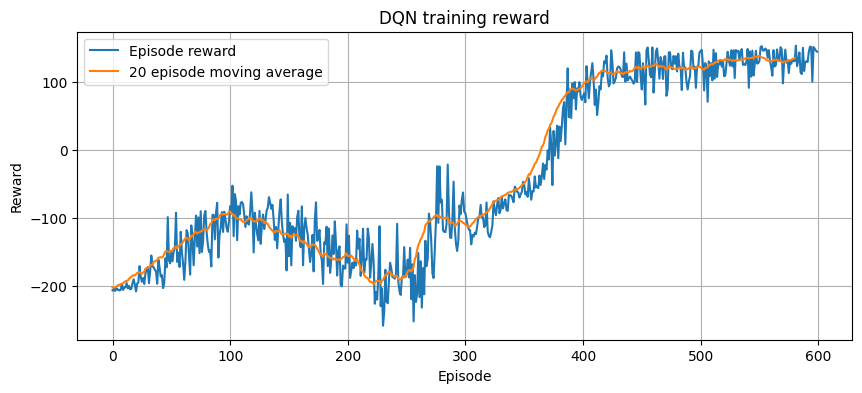

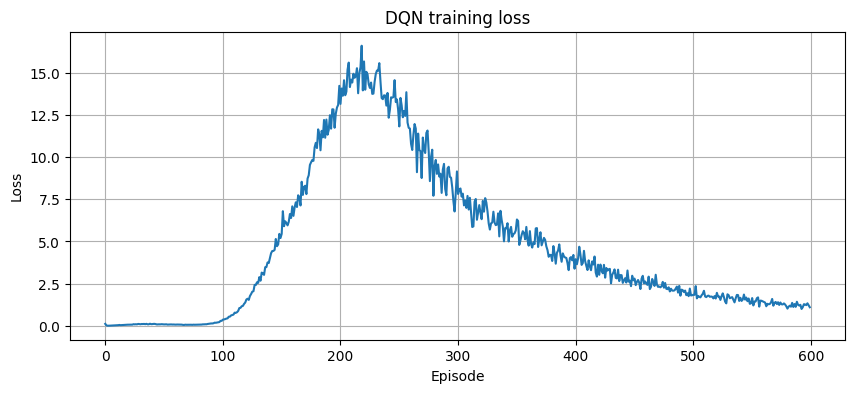

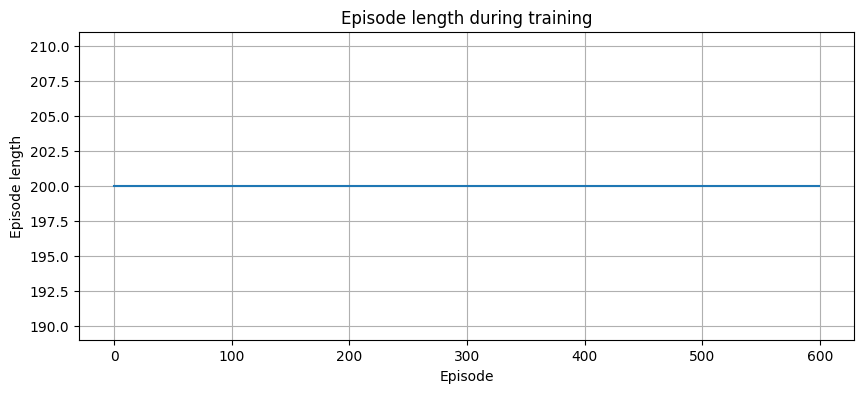

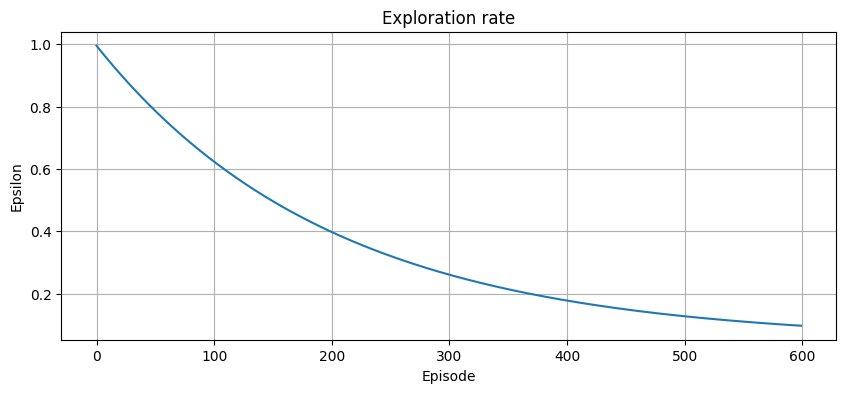

In [85]:
import matplotlib.pyplot as plt

def moving_average(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(history["episode_rewards"], label="Episode reward")
plt.plot(
    range(len(moving_average(history["episode_rewards"], 20))),
    moving_average(history["episode_rewards"], 20),
    label="20 episode moving average"
)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN training reward")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["losses"])
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.title("DQN training loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["episode_lengths"])
plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("Episode length during training")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["epsilons"])
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration rate")
plt.grid(True)
plt.show()

### Evaluate the model

In [86]:
def evaluate_policy(env, policy_net, episodes=20, render=False):
    policy_net.eval()

    rewards = []
    lengths = []
    mean_abs_u = []
    mean_abs_du = []
    mean_abs_angle_error = []
    mean_abs_omega = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False

        total_reward = 0
        episode_length = 0

        u_values = []
        angle_errors = []
        omega_values = []

        prev_u = 0

        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

            with torch.no_grad():
                q_values = policy_net(state_tensor)
                action = q_values.argmax().item()

            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            base_env = env.unwrapped

            u = float(base_env.u)
            th = float(base_env.th)
            omega = float(base_env.omega)

            # angle error relative to upright position pi
            angle_error = ((th - np.pi + np.pi) % (2 * np.pi)) - np.pi

            u_values.append(u)
            angle_errors.append(abs(angle_error))
            omega_values.append(abs(omega))

            total_reward += reward
            episode_length += 1

            if render:
                env.render()

        rewards.append(total_reward)
        lengths.append(episode_length)
        mean_abs_u.append(np.mean(np.abs(u_values)))
        mean_abs_du.append(np.mean(np.abs(np.diff(u_values))) if len(u_values) > 1 else 0)
        mean_abs_angle_error.append(np.mean(angle_errors))
        mean_abs_omega.append(np.mean(omega_values))

    results = {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_length": np.mean(lengths),
        "mean_abs_u": np.mean(mean_abs_u),
        "mean_abs_du": np.mean(mean_abs_du),
        "mean_abs_angle_error": np.mean(mean_abs_angle_error),
        "mean_abs_omega": np.mean(mean_abs_omega),
    }

    return results

results = evaluate_policy(env, trained_policy, episodes=20, render=False)

for key, value in results.items():
    print(f"{key}: {value:.4f}")

mean_reward: 150.4463
std_reward: 0.5476
mean_length: 200.0000
mean_abs_u: 1.6688
mean_abs_du: 1.8258
mean_abs_angle_error: 0.4339
mean_abs_omega: 1.4258
